## **Train a Deep Learning Model With Pytorch**

Neural Network is a type of machine learning model inspired by the structure and function of human brain. It consists of layers of interconnected nodes called neurons which process and transmit information. Neural networks are particularly well-suited for tasks such as image and speech recognition, natural language processing and making predictions based on large amounts of data.

## Implementing Deep Neural Network

We will train a neural network on the MNIST dataset. It is a dataset of handwritten digits consisting of 60,000 training examples and 10,000 test examples. Each example is a 28x28 grayscale image of a handwritten digit with values ranging from 0 (white) to 255 (black). The label for each example is the digit that the image represents with values ranging from 0 to 9.



### 1. Importing necessary Libraries

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

### 2. Loading MNIST Datasets

* **transforms.Compose:** A sequence of transformations to apply to the images.
* **ToTensor():** Converts images into PyTorch tensors.
* **Normalize():** Normalizes the pixel values to the range [-1, 1].
* **DataLoader:** DataLoader is a utility class that handles the batching, shuffling and loading of data for training and evaluation.
* **batch_size=64:** means that in each iteration 64 samples will be processed at once.

In [6]:
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5,), (0.5,))]
)

trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

100%|██████████| 9.91M/9.91M [00:09<00:00, 1.02MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 115kB/s]
100%|██████████| 1.65M/1.65M [00:02<00:00, 763kB/s] 
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.27MB/s]


### 3. Building model

* **nn.Module:** The base class for all neural network modules in PyTorch. By inheriting from this class we create a custom model with layers and a forward pass.
* **nn.Linear:** This is a basic layer where each input is connected to every output node.
* **fc1:** The first fully connected layer transforms the 28x28 image (flattened to a 784-length vector) into a 128-dimensional vector.
* **fc2:** The second fully connected layer outputs a 10-dimensional vector corresponding to the 10 possible digit classes.
* **ReLU activation:** We use ReLU activation after the first layer to introduce non-linearity.

In [7]:
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(28*28, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = x.view(-1, 28*28)  # Flatten the input
        x = torch.relu(self.fc1(x))  # Apply ReLU activation
        x = self.fc2(x)  # Output layer
        return x

model = SimpleNN()

### 4. Defining the Loss Function and Optimizer

* CrossEntropyLoss: Measures the difference between the predicted and true labels.
* Adam: A popular optimization algorithm that adapts the learning rate during training.
* lr=0.001 sets the learning rate which determines how much we adjust the weights during each update.

In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


### 5. Training the Model

* **loss.backward():** Computes gradients for each model parameter.
* **optimizer.step():** Updates the model's weights using the gradients.
* **cuda():** If a GPU is available we move the images, labels and model to the GPU for faster computation.
* **optimizer.zero_grad():** Before performing a backward pass we need to set all the gradients to zero. Otherwise the gradients will accumulate from previous iterations.
* **loss.backward():** This computes the gradients for the model’s weights indicating how much the weights need to be adjusted.
* **optimizer.step():** This updates the model’s weights based on the gradients calculated during the backward pass.

In [9]:
train_losses = []
num_epochs = 5

for epoch in range(num_epochs):
    running_loss = 0.0
    for i, (images, labels) in enumerate(trainloader):
        if torch.cuda.is_available():
            images, labels = images.cuda(), labels.cuda()
            model = model.cuda()
        else:
            model.cpu()
        
        optimizer.zero_grad()  # Zero the parameter gradients

        outputs = model(images)  # Forward pass
        loss = criterion(outputs, labels)  # Compute loss

        loss.backward()  # Backward pass
        optimizer.step()  # Update weights

        running_loss += loss.item()

        if i % 100 == 99:  # Print every 100 mini-batches
            print(f'Epoch [{epoch + 1}/{num_epochs}], Step [{i + 1}/{len(trainloader)}], Loss: {running_loss / 100:.4f}')
            train_losses.append(running_loss / 100)
            running_loss = 0.0


Epoch [1/5], Step [100/938], Loss: 0.9157
Epoch [1/5], Step [200/938], Loss: 0.4237
Epoch [1/5], Step [300/938], Loss: 0.3722
Epoch [1/5], Step [400/938], Loss: 0.3579
Epoch [1/5], Step [500/938], Loss: 0.3433
Epoch [1/5], Step [600/938], Loss: 0.3037
Epoch [1/5], Step [700/938], Loss: 0.3170
Epoch [1/5], Step [800/938], Loss: 0.2802
Epoch [1/5], Step [900/938], Loss: 0.2616
Epoch [2/5], Step [100/938], Loss: 0.2416
Epoch [2/5], Step [200/938], Loss: 0.2163
Epoch [2/5], Step [300/938], Loss: 0.2160
Epoch [2/5], Step [400/938], Loss: 0.2084
Epoch [2/5], Step [500/938], Loss: 0.2224
Epoch [2/5], Step [600/938], Loss: 0.2067
Epoch [2/5], Step [700/938], Loss: 0.1962
Epoch [2/5], Step [800/938], Loss: 0.1908
Epoch [2/5], Step [900/938], Loss: 0.1766
Epoch [3/5], Step [100/938], Loss: 0.1533
Epoch [3/5], Step [200/938], Loss: 0.1478
Epoch [3/5], Step [300/938], Loss: 0.1574
Epoch [3/5], Step [400/938], Loss: 0.1582
Epoch [3/5], Step [500/938], Loss: 0.1505
Epoch [3/5], Step [600/938], Loss:

### 6. Ploting Training and Validation Curves

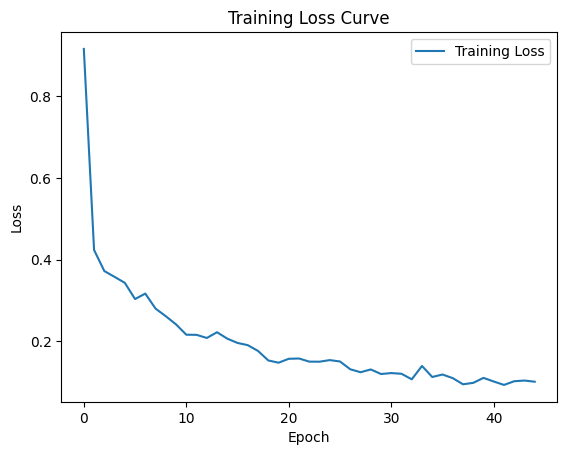

In [10]:
plt.plot(train_losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.legend()
plt.show()

### 7. Evaluating the Model

* model.eval(): Sets the model to evaluation mode disabling dropout layers.
* torch.no_grad(): Ensures that no gradients are calculated during evaluation saving memory.

In [11]:
correct = 0
total = 0

model.eval()  # Set the model to evaluation mode

with torch.no_grad():  # No need to calculate gradients during evaluation
    for images, labels in testloader:
        if torch.cuda.is_available():
            images, labels = images.cuda(), labels.cuda()
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f'Accuracy of the model on the 10000 test images: {accuracy:.2f}%')

Accuracy of the model on the 10000 test images: 96.87%
